### GITHUB LINK - https://github.com/rajsengar1804-hub/Emotion-Detection

### Project deploy link -https://emotion-detection-bu5jwif3rhwhn6z53w7ylu.streamlit.app/

In [4]:
import matplotlib.pyplot as plt 
import seaborn 
import pandas as pd 
import numpy as np 

In [ ]:
import os
import random
import tensorflow as tf


# Set random seeds for reproducibility across all model comparisons
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset paths (Kaggle)
DATASET_DIR = "/kaggle/input/datasets/rajpratapsinghsengar/emotion/dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")
CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))
print("GPU available:", tf.config.list_physical_devices('GPU'))

Train dir exists: True
Test dir exists: True
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# EDA 

In [ ]:

from PIL import Image

print("EDA imports done")

EDA imports done


# GITHUB LINK - https://github.com/rajsengar1804-hub/Emotion-Detection

In [5]:
def get_class_counts(split_dir):
    counts = {}
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = get_class_counts(TRAIN_DIR)
test_counts = get_class_counts(TEST_DIR)

print("Train counts:", train_counts)
print("Test counts:", test_counts)

Train counts: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test counts: {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


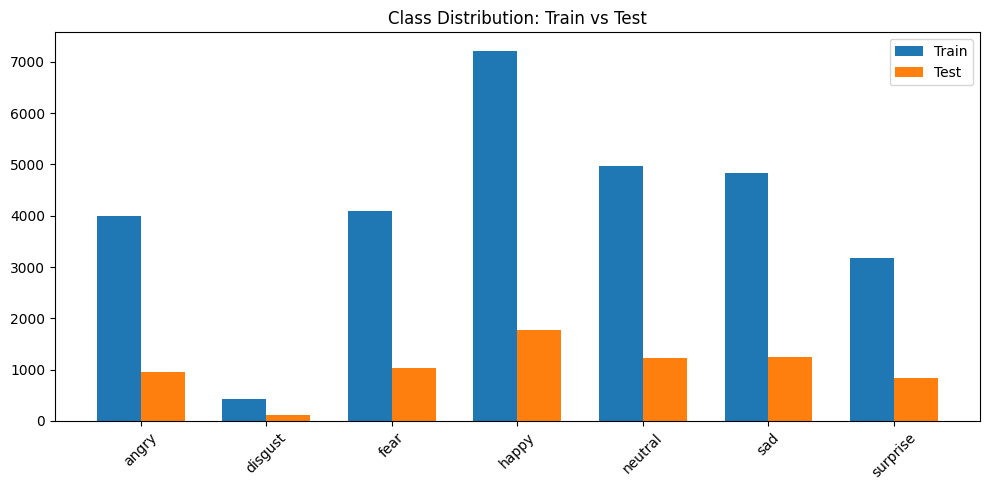

Imbalance ratio (train, max/min): 16.55


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(CLASSES))
width = 0.35
ax.bar([i - width/2 for i in x], train_counts.values(), width, label='Train')
ax.bar([i + width/2 for i in x], test_counts.values(), width, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45)
ax.legend()
ax.set_title("Class Distribution: Train vs Test")
plt.tight_layout()
plt.show()

print(f"Imbalance ratio (train, max/min): {max(train_counts.values()) / min(train_counts.values()):.2f}")

#### The dataset shows a clear class imbalance across both train and test splits:

Happy is the majority class by a wide margin (~7,200 train / ~1,770 test), roughly 17x larger than the smallest class.
Disgust is severely underrepresented (~430 train / ~110 test) — less than 6% of the size of the happy class.
Neutral and sad form a mid-tier group (~4,800–5,000 train samples each), followed by fear and angry (~4,000–4,100 train), with surprise slightly lower (~3,200 train).
The train-to-test ratio is roughly consistent (~4.2:1) across all classes, meaning the split preserves the original class proportions — so the imbalance isn't a splitting artifact, it's inherent to the source data.

## Sample image visualization

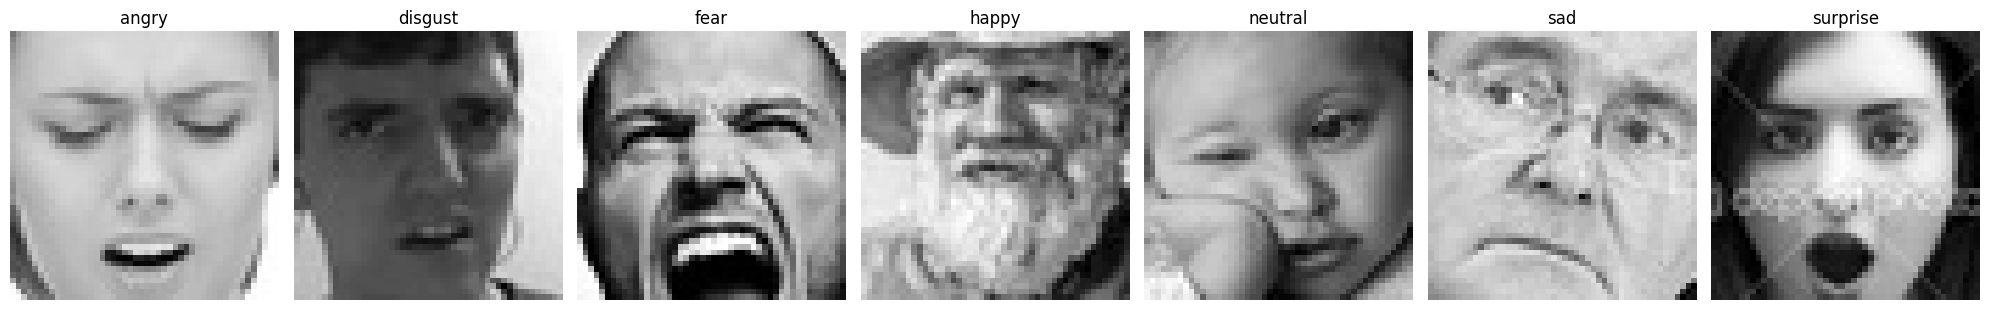

In [7]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4))
for ax, cls in zip(axes, CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample_img = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, sample_img))
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Full scan function (dimensions, color mode, pixel range, corrupt files)

In [8]:
def full_image_scan(split_dir):
    dims = []
    modes = []
    pixel_mins, pixel_maxs = [], []
    corrupt_files = []

    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath)
                img.verify()
                img = Image.open(fpath)
                dims.append(img.size)
                modes.append(img.mode)
                arr = np.array(img)
                pixel_mins.append(arr.min())
                pixel_maxs.append(arr.max())
            except Exception as e:
                corrupt_files.append((fpath, str(e)))

    return dims, modes, pixel_mins, pixel_maxs, corrupt_files

In [9]:
train_dims, train_modes, train_pmins, train_pmaxs, train_corrupt = full_image_scan(TRAIN_DIR)

print("Unique dimensions:", set(train_dims))
print("Unique color modes:", set(train_modes))
print(f"Pixel value range: min={min(train_pmins)}, max={max(train_pmaxs)}")
print(f"Corrupt/unreadable files: {len(train_corrupt)}")

Unique dimensions: {(48, 48)}
Unique color modes: {'L'}
Pixel value range: min=0, max=255
Corrupt/unreadable files: 0


## Train vs test proportion comparison

In [10]:
train_total = sum(train_counts.values())
test_total = sum(test_counts.values())

print("Class proportions (train vs test):")
for cls in CLASSES:
    train_pct = train_counts[cls] / train_total * 100
    test_pct = test_counts[cls] / test_total * 100
    print(f"{cls:10s} train: {train_pct:.1f}%  test: {test_pct:.1f}%")

Class proportions (train vs test):
angry      train: 13.9%  test: 13.3%
disgust    train: 1.5%  test: 1.5%
fear       train: 14.3%  test: 14.3%
happy      train: 25.1%  test: 24.7%
neutral    train: 17.3%  test: 17.2%
sad        train: 16.8%  test: 17.4%
surprise   train: 11.0%  test: 11.6%


## Observation 


##### The train and test sets show very similar class proportions, indicating the split is well-stratified and representative:

##### Happy is the dominant class (~25% in both splits), roughly one in every four samples.
##### Disgust is the smallest class by a large margin (~1.5% in both splits) — about 17x smaller than happy — indicating a severe class imbalance.
##### Neutral (~17%) and sad (~17%) form a consistent mid-tier, followed by fear (~14%) and angry (~13–14%).
##### Surprise is moderately underrepresented (~11–12%).
##### The maximum train-test deviation across any class is under 1 percentage point (e.g., sad: 16.8% vs 17.4%), confirming the split preserves the original distribution well — there's no meaningful distribution shift between train and test.

#

# Data PreProcessing 

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 48
print("Preprocessing imports done")

Preprocessing imports done


In [12]:
def load_data(split_dir):
    images = []
    labels = []
    for idx, cls in enumerate(CLASSES):
        cls_path = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            img = Image.open(fpath).convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img))
            labels.append(idx)
    return np.array(images), np.array(labels)

X_train_full, y_train_full = load_data(TRAIN_DIR)
X_test, y_test = load_data(TEST_DIR)

print("Train shape:", X_train_full.shape, "Labels shape:", y_train_full.shape)
print("Test shape:", X_test.shape, "Labels shape:", y_test.shape)

Train shape: (28709, 48, 48) Labels shape: (28709,)
Test shape: (7178, 48, 48) Labels shape: (7178,)


In [13]:
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = np.expand_dims(X_train_full, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Train shape after channel expansion:", X_train_full.shape)
print("Test shape after channel expansion:", X_test.shape)

Train shape after channel expansion: (28709, 48, 48, 1)
Test shape after channel expansion: (7178, 48, 48, 1)


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (24402, 48, 48, 1) Val: (4307, 48, 48, 1)


In [15]:
y_train_cat = to_categorical(y_train, num_classes=len(CLASSES))
y_val_cat = to_categorical(y_val, num_classes=len(CLASSES))
y_test_cat = to_categorical(y_test, num_classes=len(CLASSES))
y_true = np.argmax(y_test_cat, axis=1)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

y_train_cat shape: (24402, 7)
y_val_cat shape: (4307, 7)
y_test_cat shape: (7178, 7)


In [16]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0265017667844523), 1: np.float64(9.39622641509434), 2: np.float64(1.0011487650775417), 3: np.float64(0.5684004565465515), 4: np.float64(0.8260663507109005), 5: np.float64(0.8492082825822168), 6: np.float64(1.2935064935064935)}


In [17]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_datagen.fit(X_train)
print("Augmentation generator ready")

Augmentation generator ready


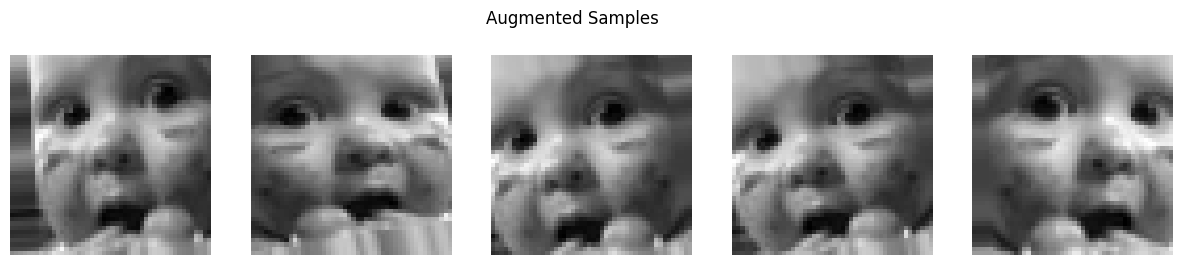

In [18]:
sample_img = X_train[0].reshape(1, IMG_SIZE, IMG_SIZE, 1)
aug_iter = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    aug_img = next(aug_iter)[0].reshape(IMG_SIZE, IMG_SIZE)
    ax.imshow(aug_img, cmap='gray')
    ax.axis('off')
plt.suptitle("Augmented Samples")
plt.show()

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(CLASSES), activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,469,152 (5.60 MB)

 Trainable params: 1,467,744 (5.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [5]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

In [ ]:
BATCH_SIZE = 64
EPOCHS = 50

history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

#### Model is train on google colab and below is the Training procedure 

Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step - accuracy: 0.1836 - loss: 2.2990 - val_accuracy: 0.1934 - val_loss: 1.9098 - learning_rate: 0.0010
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.2423 - loss: 1.9122 - val_accuracy: 0.3413 - val_loss: 1.6803 - learning_rate: 0.0010
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3206 - loss: 1.7166 - val_accuracy: 0.4207 - val_loss: 1.4917 - learning_rate: 0.0010
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3720 - loss: 1.6199 - val_accuracy: 0.4249 - val_loss: 1.5086 - learning_rate: 0.0010
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4008 - loss: 1.5447 - val_accuracy: 0.4767 - val_loss: 1.3714 - learning_rate: 0.0010
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4251 - loss: 1.4918 - val_accuracy: 0.4611 - val_loss: 1.4330 - learning_rate: 0.0010
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4543 - loss: 1.4227 - val_accuracy: 0.5064 - val_loss: 1.2787 - learning_rate: 0.0010
Epoch 8/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4645 - loss: 1.3982 - val_accuracy: 0.3736 - val_loss: 1.5976 - learning_rate: 0.0010
Epoch 9/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4753 - loss: 1.3706 - val_accuracy: 0.5115 - val_loss: 1.2908 - learning_rate: 0.0010
Epoch 10/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4820 - loss: 1.3416 - val_accuracy: 0.5062 - val_loss: 1.2910 - learning_rate: 0.0010
Epoch 11/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4920 - loss: 1.3317 - val_accuracy: 0.5287 - val_loss: 1.2392 - learning_rate: 0.0010
Epoch 12/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.5050 - loss: 1.2995 - val_accuracy: 0.4941 - val_loss: 1.3214 - learning_rate: 0.0010
Epoch 13/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5096 - loss: 1.2781 - val_accuracy: 0.5375 - val_loss: 1.2108 - learning_rate: 0.0010
Epoch 14/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5168 - loss: 1.2478 - val_accuracy: 0.5247 - val_loss: 1.2407 - learning_rate: 0.0010
Epoch 15/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5260 - loss: 1.2418 - val_accuracy: 0.5398 - val_loss: 1.2018 - learning_rate: 0.0010
Epoch 16/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5255 - loss: 1.2365 - val_accuracy: 0.5582 - val_loss: 1.1447 - learning_rate: 0.0010
Epoch 17/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5284 - loss: 1.2235 - val_accuracy: 0.5579 - val_loss: 1.1326 - learning_rate: 0.0010
Epoch 18/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5389 - loss: 1.1929 - val_accuracy: 0.5250 - val_loss: 1.2878 - learning_rate: 0.0010
Epoch 19/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5448 - loss: 1.1640 - val_accuracy: 0.2974 - val_loss: 1.7609 - learning_rate: 0.0010
Epoch 20/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5482 - loss: 1.1651 - val_accuracy: 0.5816 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 21/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5526 - loss: 1.1521 - val_accuracy: 0.5609 - val_loss: 1.1512 - learning_rate: 0.0010
Epoch 22/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5506 - loss: 1.1583 - val_accuracy: 0.5366 - val_loss: 1.2010 - learning_rate: 0.0010
Epoch 23/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.5499 - loss: 1.1591 - val_accuracy: 0.5900 - val_loss: 1.0597 - learning_rate: 0.0010
Epoch 24/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5625 - loss: 1.1245 - val_accuracy: 0.5558 - val_loss: 1.2038 - learning_rate: 0.0010
Epoch 25/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5669 - loss: 1.1031 - val_accuracy: 0.5851 - val_loss: 1.1045 - learning_rate: 0.0010
Epoch 26/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5682 - loss: 1.1081 - val_accuracy: 0.5930 - val_loss: 1.0721 - learning_rate: 0.0010
Epoch 27/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5695 - loss: 1.1075 - val_accuracy: 0.5760 - val_loss: 1.1125 - learning_rate: 0.0010
Epoch 28/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5792 - loss: 1.0567 - val_accuracy: 0.5979 - val_loss: 1.0591 - learning_rate: 5.0000e-04
Epoch 29/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.5895 - loss: 1.0471 - val_accuracy: 0.6081 - val_loss: 1.0426 - learning_rate: 5.0000e-04
Epoch 30/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5934 - loss: 1.0309 - val_accuracy: 0.5948 - val_loss: 1.0700 - learning_rate: 5.0000e-04
Epoch 31/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5997 - loss: 1.0110 - val_accuracy: 0.6204 - val_loss: 0.9988 - learning_rate: 5.0000e-04
Epoch 32/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5963 - loss: 1.0168 - val_accuracy: 0.6169 - val_loss: 1.0082 - learning_rate: 5.0000e-04
Epoch 33/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6008 - loss: 1.0093 - val_accuracy: 0.6065 - val_loss: 1.0309 - learning_rate: 5.0000e-04
Epoch 34/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6050 - loss: 1.0053 - val_accuracy: 0.6034 - val_loss: 1.0428 - learning_rate: 5.0000e-04
Epoch 35/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6047 - loss: 1.0032 - val_accuracy: 0.6090 - val_loss: 1.0303 - learning_rate: 5.0000e-04
Epoch 36/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.6140 - loss: 0.9741 - val_accuracy: 0.6318 - val_loss: 0.9729 - learning_rate: 2.5000e-04
Epoch 37/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6103 - loss: 0.9759 - val_accuracy: 0.6206 - val_loss: 1.0118 - learning_rate: 2.5000e-04
Epoch 38/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6152 - loss: 0.9597 - val_accuracy: 0.6274 - val_loss: 0.9719 - learning_rate: 2.5000e-04
Epoch 39/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6201 - loss: 0.9568 - val_accuracy: 0.6294 - val_loss: 0.9898 - learning_rate: 2.5000e-04
Epoch 40/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6181 - loss: 0.9549 - val_accuracy: 0.6332 - val_loss: 0.9621 - learning_rate: 2.5000e-04
Epoch 41/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6194 - loss: 0.9539 - val_accuracy: 0.6306 - val_loss: 0.9760 - learning_rate: 2.5000e-04
Epoch 42/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6154 - loss: 0.9603 - val_accuracy: 0.6364 - val_loss: 0.9645 - learning_rate: 2.5000e-04
Epoch 43/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.6217 - loss: 0.9437 - val_accuracy: 0.6304 - val_loss: 0.9743 - learning_rate: 2.5000e-04
Epoch 44/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6241 - loss: 0.9359 - val_accuracy: 0.6369 - val_loss: 0.9693 - learning_rate: 2.5000e-04
Epoch 45/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6253 - loss: 0.9211 - val_accuracy: 0.6436 - val_loss: 0.9588 - learning_rate: 1.2500e-04
Epoch 46/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6285 - loss: 0.9265 - val_accuracy: 0.6399 - val_loss: 0.9657 - learning_rate: 1.2500e-04
Epoch 47/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6289 - loss: 0.9170 - val_accuracy: 0.6397 - val_loss: 0.9543 - learning_rate: 1.2500e-04
Epoch 48/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6323 - loss: 0.9126 - val_accuracy: 0.6429 - val_loss: 0.9529 - learning_rate: 1.2500e-04
Epoch 49/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6278 - loss: 0.9136 - val_accuracy: 0.6355 - val_loss: 0.9598 - learning_rate: 1.2500e-04
Epoch 50/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6336 - loss: 0.9072 - val_accuracy: 0.6401 - val_loss: 0.9487 - learning_rate: 1.2500e-04


In [8]:
!pip install keras-tuner -q

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [9]:
def build_model(hp):
    model = Sequential()

    # Tune number of conv blocks
    for i in range(hp.Int('conv_blocks', 2, 3)):
        filters = hp.Choice(f'filters_{i}', values=[32, 64, 128])
        model.add(Conv2D(filters, (3,3), activation='relu', padding='same',
                          input_shape=(48,48,1) if i == 0 else None))
        model.add(BatchNormalization())
        model.add(MaxPooling2D((2,2)))
        model.add(Dropout(hp.Float(f'conv_dropout_{i}', 0.2, 0.4, step=0.1)))

    model.add(Flatten())

    # Tune dense layer size
    dense_units = hp.Choice('dense_units', values=[128, 256, 512])
    model.add(Dense(dense_units, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dense_dropout', 0.3, 0.5, step=0.1)))

    model.add(Dense(len(CLASSES), activation='softmax'))

    # Tune learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,          # number of different configs to try
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='deepfer_tuning'
)

tuner.search_space_summary()

Search space summary
Default search space size: 8
conv_blocks (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
filters_0 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
conv_dropout_0 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
filters_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
conv_dropout_1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dense_dropout (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(
    train_datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=15,              
    class_weight=class_weight_dict
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history_tuned = best_model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.4266 - loss: 1.4866 - val_accuracy: 0.4291 - val_loss: 1.4699 - learning_rate: 0.0010
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.4345 - loss: 1.4587 - val_accuracy: 0.4024 - val_loss: 1.5796 - learning_rate: 0.0010
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4369 - loss: 1.4552 - val_accuracy: 0.4860 - val_loss: 1.4596 - learning_rate: 0.0010
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4409 - loss: 1.4431 - val_accuracy: 0.4495 - val_loss: 1.4834 - learning_rate: 0.0010
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.4513 - loss: 1.4295 - val_accuracy: 0.5066 - val_loss: 1.3186 - learning_rate: 0.0010
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4567 - loss: 1.4053 - val_accuracy: 0.4017 - val_loss: 1.5698 - learning_rate: 0.0010
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4499 - loss: 1.4184 - val_accuracy: 0.4834 - val_loss: 1.3988 - learning_rate: 0.0010
Epoch 8/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.4533 - loss: 1.4129 - val_accuracy: 0.4813 - val_loss: 1.6339 - learning_rate: 0.0010
Epoch 9/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4589 - loss: 1.3946 - val_accuracy: 0.3134 - val_loss: 1.8332 - learning_rate: 0.0010
Epoch 10/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4693 - loss: 1.3633 - val_accuracy: 0.4994 - val_loss: 1.3610 - learning_rate: 5.0000e-04
Epoch 11/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.4846 - loss: 1.3344 - val_accuracy: 0.5171 - val_loss: 1.2587 - learning_rate: 5.0000e-04
Epoch 12/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.4877 - loss: 1.3165 - val_accuracy: 0.5075 - val_loss: 1.3479 - learning_rate: 5.0000e-04
Epoch 13/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4829 - loss: 1.3160 - val_accuracy: 0.5261 - val_loss: 1.2468 - learning_rate: 5.0000e-04
Epoch 14/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4905 - loss: 1.3189 - val_accuracy: 0.5324 - val_loss: 1.2534 - learning_rate: 5.0000e-04
Epoch 15/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.4974 - loss: 1.2893 - val_accuracy: 0.5252 - val_loss: 1.2460 - learning_rate: 5.0000e-04
Epoch 16/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4960 - loss: 1.2845 - val_accuracy: 0.5222 - val_loss: 1.2453 - learning_rate: 5.0000e-04
Epoch 17/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4972 - loss: 1.2792 - val_accuracy: 0.5068 - val_loss: 1.3020 - learning_rate: 5.0000e-04
Epoch 18/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.4964 - loss: 1.2915 - val_accuracy: 0.5456 - val_loss: 1.2027 - learning_rate: 5.0000e-04
Epoch 19/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.5025 - loss: 1.2701 - val_accuracy: 0.5268 - val_loss: 1.2294 - learning_rate: 5.0000e-04
Epoch 20/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5018 - loss: 1.2848 - val_accuracy: 0.5250 - val_loss: 1.2524 - learning_rate: 5.0000e-04
Epoch 21/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5022 - loss: 1.2760 - val_accuracy: 0.5129 - val_loss: 1.2630 - learning_rate: 5.0000e-04
Epoch 22/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5095 - loss: 1.2508 - val_accuracy: 0.5414 - val_loss: 1.2095 - learning_rate: 5.0000e-04
Epoch 23/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5179 - loss: 1.2256 - val_accuracy: 0.5491 - val_loss: 1.1770 - learning_rate: 2.5000e-04
Epoch 24/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5198 - loss: 1.2215 - val_accuracy: 0.5431 - val_loss: 1.1948 - learning_rate: 2.5000e-04
Epoch 25/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5199 - loss: 1.2224 - val_accuracy: 0.5303 - val_loss: 1.2196 - learning_rate: 2.5000e-04
Epoch 26/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5216 - loss: 1.2137 - val_accuracy: 0.5596 - val_loss: 1.1671 - learning_rate: 2.5000e-04
Epoch 27/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5273 - loss: 1.1943 - val_accuracy: 0.5544 - val_loss: 1.1684 - learning_rate: 2.5000e-04
Epoch 28/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.5275 - loss: 1.1938 - val_accuracy: 0.5598 - val_loss: 1.1561 - learning_rate: 2.5000e-04
Epoch 29/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5270 - loss: 1.1982 - val_accuracy: 0.5561 - val_loss: 1.1810 - learning_rate: 2.5000e-04
Epoch 30/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.5302 - loss: 1.1992 - val_accuracy: 0.5489 - val_loss: 1.1816 - learning_rate: 2.5000e-04
Epoch 31/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5348 - loss: 1.1763 - val_accuracy: 0.5394 - val_loss: 1.2276 - learning_rate: 2.5000e-04
Epoch 32/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5286 - loss: 1.2008 - val_accuracy: 0.5496 - val_loss: 1.1751 - learning_rate: 2.5000e-04
Epoch 33/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.5297 - loss: 1.1827 - val_accuracy: 0.5579 - val_loss: 1.1865 - learning_rate: 1.2500e-04
Epoch 34/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5353 - loss: 1.1760 - val_accuracy: 0.5554 - val_loss: 1.1586 - learning_rate: 1.2500e-04
Epoch 35/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5370 - loss: 1.1805 - val_accuracy: 0.5568 - val_loss: 1.1808 - learning_rate: 1.2500e-04
Epoch 36/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.5384 - loss: 1.1763 - val_accuracy: 0.5586 - val_loss: 1.1531 - learning_rate: 1.2500e-04
Epoch 37/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5382 - loss: 1.1644 - val_accuracy: 0.5521 - val_loss: 1.1896 - learning_rate: 1.2500e-04
Epoch 38/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5391 - loss: 1.1678 - val_accuracy: 0.5544 - val_loss: 1.1699 - learning_rate: 1.2500e-04
Epoch 39/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.5376 - loss: 1.1549 - val_accuracy: 0.5661 - val_loss: 1.1517 - learning_rate: 1.2500e-04
Epoch 40/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5404 - loss: 1.1662 - val_accuracy: 0.5533 - val_loss: 1.1853 - learning_rate: 1.2500e-04
Epoch 41/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5358 - loss: 1.1690 - val_accuracy: 0.5507 - val_loss: 1.1906 - learning_rate: 1.2500e-04
Epoch 42/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5403 - loss: 1.1558 - val_accuracy: 0.5663 - val_loss: 1.1474 - learning_rate: 1.2500e-04
Epoch 43/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5398 - loss: 1.1488 - val_accuracy: 0.5672 - val_loss: 1.1472 - learning_rate: 1.2500e-04
Epoch 44/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5418 - loss: 1.1568 - val_accuracy: 0.5674 - val_loss: 1.1448 - learning_rate: 1.2500e-04
Epoch 45/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5401 - loss: 1.1724 - val_accuracy: 0.5686 - val_loss: 1.1493 - learning_rate: 1.2500e-04
Epoch 46/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5418 - loss: 1.1496 - val_accuracy: 0.5619 - val_loss: 1.1690 - learning_rate: 1.2500e-04
Epoch 47/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5444 - loss: 1.1434 - val_accuracy: 0.5568 - val_loss: 1.1545 - learning_rate: 1.2500e-04
Epoch 48/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5402 - loss: 1.1508 - val_accuracy: 0.5609 - val_loss: 1.1500 - learning_rate: 1.2500e-04
Epoch 49/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5409 - loss: 1.1427 - val_accuracy: 0.5672 - val_loss: 1.1415 - learning_rate: 6.2500e-05
Epoch 50/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5466 - loss: 1.1465 - val_accuracy: 0.5684 - val_loss: 1.1478 - learning_rate: 6.2500e-05


In [19]:
results = {
    'CNN_Scratch': {'accuracy': 0.6333, 'precision': 0.64, 'recall': 0.63, 'f1_score': 0.63},
    'CNN_Tuned': {'accuracy': 0.6103, 'precision': 0.61, 'recall': 0.61, 'f1_score': 0.60}
}
print(results)

{'CNN_Scratch': {'accuracy': 0.6333, 'precision': 0.64, 'recall': 0.63, 'f1_score': 0.63}, 'CNN_Tuned': {'accuracy': 0.6103, 'precision': 0.61, 'recall': 0.61, 'f1_score': 0.6}}


In [20]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16, DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print("Transfer learning imports done")

Transfer learning imports done


In [22]:
IMG_SIZE_TL = 224
BATCH_SIZE_TL = 32

def preprocess_tf(image, label):
    image = image * 255.0
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, [IMG_SIZE_TL, IMG_SIZE_TL])
    return image, label

def make_base_dataset(X, y, batch_size=BATCH_SIZE_TL, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_base = make_base_dataset(X_train, y_train_cat, shuffle=True)
val_ds_base = make_base_dataset(X_val, y_val_cat)
test_ds_base = make_base_dataset(X_test, y_test_cat)
print("TL datasets ready")

I0000 00:00:1785593450.807445      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785593450.811430      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TL datasets ready


In [22]:
for images, labels in train_ds_base.take(1):
    print("Pixel range:", images.numpy().min(), "-", images.numpy().max())

Pixel range: 0.0 - 255.0


In [23]:
for images, labels in train_ds_base.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32, 7)


In [30]:
def build_transfer_model(base_model_class, input_shape=(224,224,3), name="model"):
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    output = Dense(len(CLASSES), activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output, name=name)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Model builder function ready")

Model builder function ready


In [31]:
def run_transfer_model(base_model_class, preprocess_fn, name, epochs=20):
    def apply_preprocess(image, label):
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    model = build_transfer_model(base_model_class, name=name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr]
    )

    test_loss, test_acc = model.evaluate(test_ds)
    print(f"{name} Test Accuracy: {test_acc:.4f}")

    y_pred = np.argmax(model.predict(test_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    results[name] = {'accuracy': test_acc, 'precision': precision, 'recall': recall, 'f1_score': f1}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'Accuracy ({name})')
    axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'Loss ({name})')
    axes[1].legend()
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Purples')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    return model, history

print("Training function ready")

Training function ready


Epoch 1/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - accuracy: 0.3152 - loss: 1.7306 - val_accuracy: 0.3912 - val_loss: 1.5583 - learning_rate: 0.0010
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3828 - loss: 1.5760 - val_accuracy: 0.3661 - val_loss: 1.6142 - learning_rate: 0.0010
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4087 - loss: 1.4924 - val_accuracy: 0.4767 - val_loss: 1.4127 - learning_rate: 0.0010
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4212 - loss: 1.4536 - val_accuracy: 0.4507 - val_loss: 1.4287 - learning_rate: 0.0010
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4389 - loss: 1.3926 - val_accuracy: 0.4523 - val_loss: 1.4328 - learning_rate: 0.0010
Epoch 6/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4419 - loss: 1.3722 - val_accuracy: 0.4799 - val_loss: 1.3763 - learning_rate: 0.0010
Epoch 7/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4515 - l

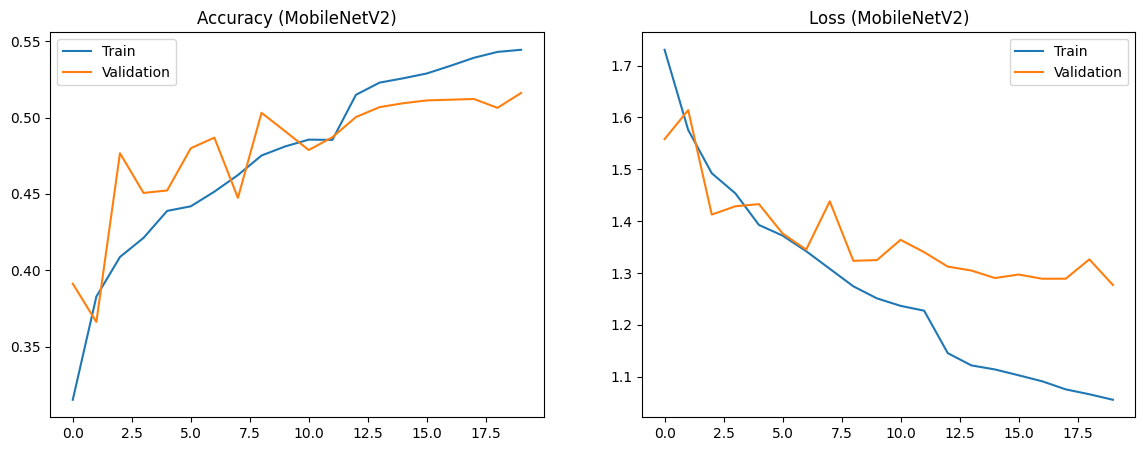

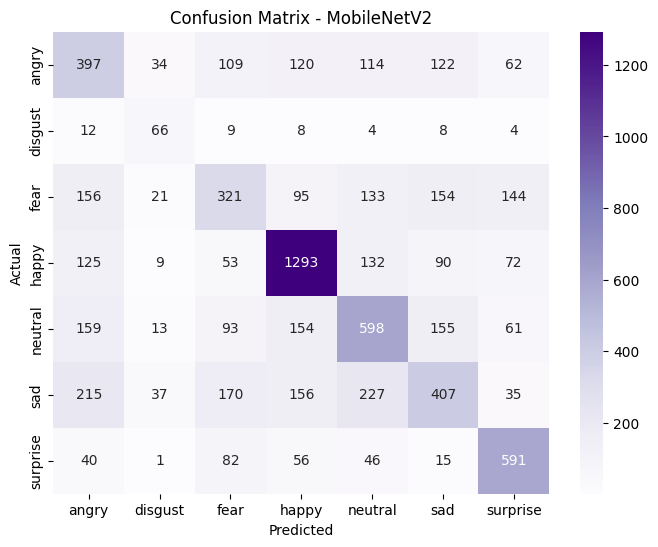

In [33]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

model_mnv2, history_mnv2 = run_transfer_model(MobileNetV2, mobilenet_preprocess, "MobileNetV2")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 101s 115ms/step - accuracy: 0.3586 - loss: 1.6837 - val_accuracy: 0.4488 - val_loss: 1.4682 - learning_rate: 0.0010
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.4256 - loss: 1.5000 - val_accuracy: 0.4804 - val_loss: 1.4008 - learning_rate: 0.0010
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.4405 - loss: 1.4451 - val_accuracy: 0.5073 - val_loss: 1.3507 - learning_rate: 0.0010
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 76s 98ms/step - accuracy: 0.4824 - loss: 1.3366 - val_accuracy: 0.4999 - val_loss: 1.3347 - learning_rate: 5.0000e-04
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.4897 - loss: 1.2951 - val_accuracy: 0.5308 - val_loss: 1.2534 - learning_rate: 5.0000e-04
Epoch 6/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.5061 - loss: 1.2542 - val_accuracy: 0.5368 - val_loss: 1.2390 - learning_rate: 5.0000e-04
Epoch 7/20


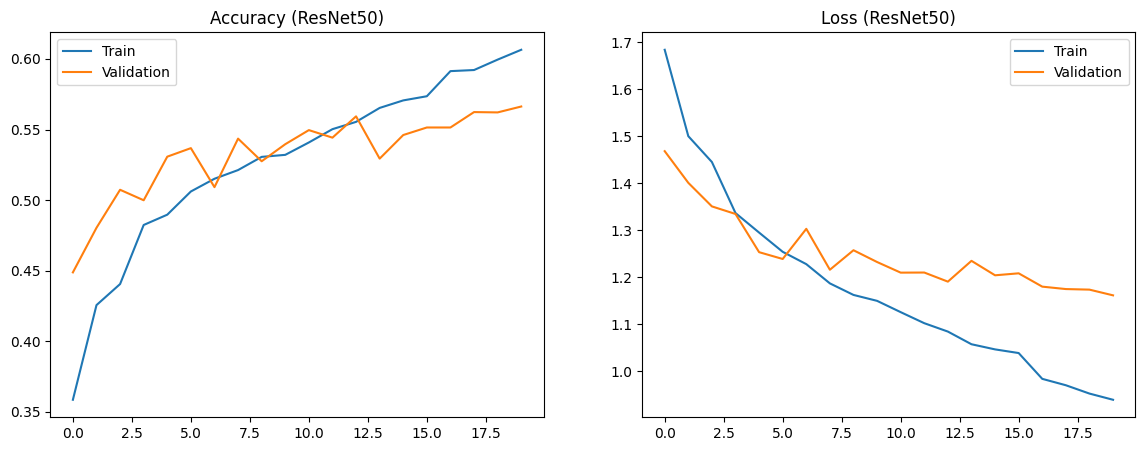

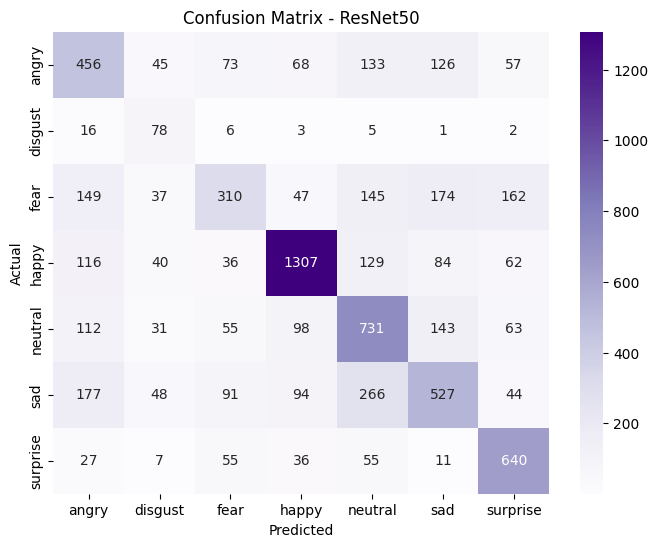

In [35]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

model_resnet, history_resnet = run_transfer_model(ResNet50, resnet_preprocess, "ResNet50")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 130s 134ms/step - accuracy: 0.3368 - loss: 1.7145 - val_accuracy: 0.4319 - val_loss: 1.5403 - learning_rate: 0.0010
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 67s 87ms/step - accuracy: 0.4078 - loss: 1.5512 - val_accuracy: 0.4418 - val_loss: 1.4605 - learning_rate: 0.0010
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 66s 86ms/step - accuracy: 0.4266 - loss: 1.4828 - val_accuracy: 0.4595 - val_loss: 1.4219 - learning_rate: 0.0010
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 66s 86ms/step - accuracy: 0.4613 - loss: 1.3962 - val_accuracy: 0.4890 - val_loss: 1.3582 - learning_rate: 5.0000e-04
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 66s 86ms/step - accuracy: 0.4698 - loss: 1.3677 - val_accuracy: 0.4850 - val_loss: 1.3545 - learning_rate: 5.0000e-04
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - accuracy: 0.4287 - loss: 1.5396
DenseNet121 Test Accuracy: 0.4287
225/225 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step
             

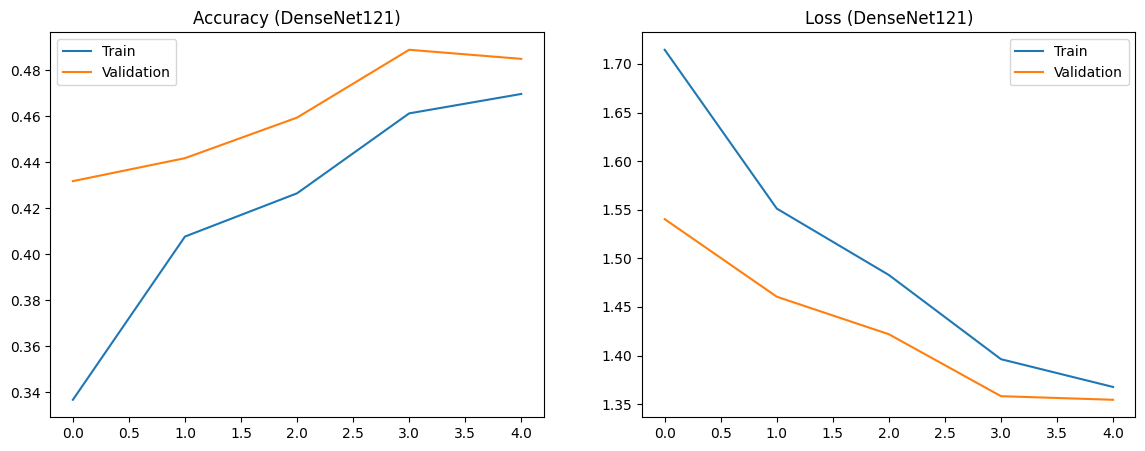

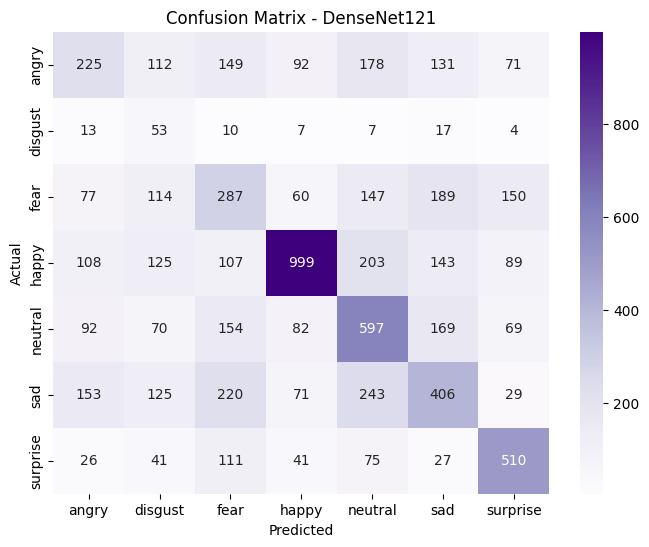

In [38]:
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

model_densenet, history_densenet = run_transfer_model(DenseNet121, densenet_preprocess, "DenseNet121")

In [ ]:


def build_transfer_model(base_model_class, input_shape=(224,224,3), name="model"):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    output = Dense(len(CLASSES), activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output, name=name)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def run_transfer_model(base_model_class, preprocess_fn, name, epochs=20):
    def apply_preprocess(image, label):
        return preprocess_fn(image), label

    train_ds = train_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    model = build_transfer_model(base_model_class, name=name)
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                         class_weight=class_weight_dict, callbacks=[early_stop, reduce_lr])

    test_loss, test_acc = model.evaluate(test_ds)
    print(f"{name} Test Accuracy: {test_acc:.4f}")

    y_pred = np.argmax(model.predict(test_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    results[name] = {'accuracy': test_acc, 'precision': precision, 'recall': recall, 'f1_score': f1}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'Accuracy ({name})')
    axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'Loss ({name})')
    axes[1].legend()
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Purples')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    return model, history

print("Setup complete")

Setup complete


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
  1/763 ━━━━━━━━━━━━━━━━━━━━ 3:11:36 15s/step - accuracy: 0.1562 - loss: 2.3585

I0000 00:00:1785586699.012720     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


763/763 ━━━━━━━━━━━━━━━━━━━━ 102s 114ms/step - accuracy: 0.3465 - loss: 1.7089 - val_accuracy: 0.4702 - val_loss: 1.4640 - learning_rate: 0.0010
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - accuracy: 0.4088 - loss: 1.5444 - val_accuracy: 0.4486 - val_loss: 1.4544 - learning_rate: 0.0010
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.4280 - loss: 1.4592 - val_accuracy: 0.4574 - val_loss: 1.4384 - learning_rate: 0.0010
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.4451 - loss: 1.4159 - val_accuracy: 0.5082 - val_loss: 1.3108 - learning_rate: 0.0010
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.4585 - loss: 1.3749 - val_accuracy: 0.5099 - val_loss: 1.3036 - learning_rate: 0.0010
Epoch 6/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.4698 - loss: 1.3398 - val_accuracy: 0.5045 - val_loss: 1.3197 - learning_rate: 0.0010
Epoch 7/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.4785 - loss

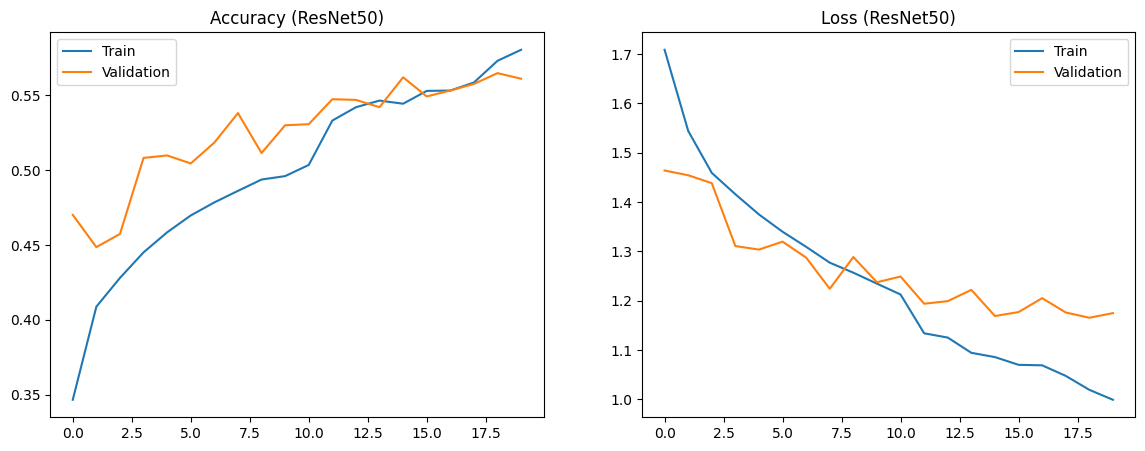

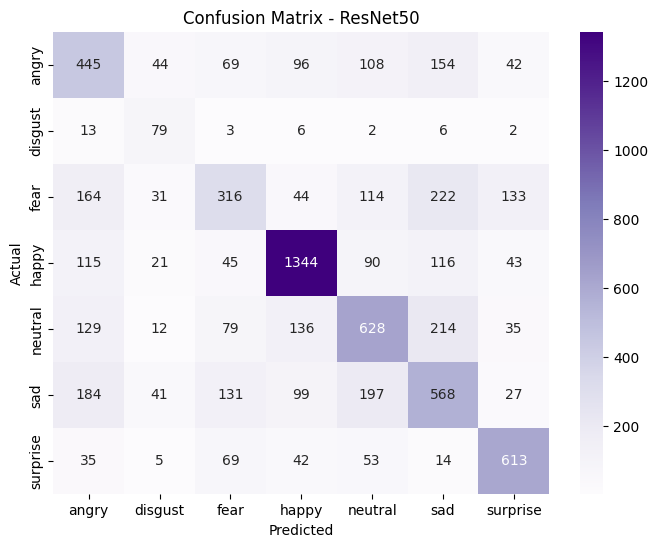

In [26]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

model_resnet, history_resnet = run_transfer_model(ResNet50, resnet_preprocess, "ResNet50")

In [ ]:

base_model = model_resnet.layers[0] if hasattr(model_resnet.layers[0], 'trainable') else None

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

base_model_ft = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_ft.trainable = True


for layer in base_model_ft.layers[:-30]:
    layer.trainable = False

x = base_model_ft.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(len(CLASSES), activation='softmax')(x)

model_resnet_ft = Model(inputs=base_model_ft.input, outputs=output, name="ResNet50_FineTuned")

model_resnet_ft.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet_ft.summary()

Model: "ResNet50_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 14,976,519 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [28]:
def apply_preprocess(image, label):
    return resnet_preprocess(image), label

train_ds_ft = train_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_ft = val_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_ft = test_ds_base.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

history_resnet_ft = model_resnet_ft.fit(
    train_ds_ft,
    validation_data=val_ds_ft,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 138s 154ms/step - accuracy: 0.3319 - loss: 1.7429 - val_accuracy: 0.4836 - val_loss: 1.3873 - learning_rate: 1.0000e-05
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 105s 137ms/step - accuracy: 0.5031 - loss: 1.2707 - val_accuracy: 0.5514 - val_loss: 1.2127 - learning_rate: 1.0000e-05
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 105s 137ms/step - accuracy: 0.5822 - loss: 1.0549 - val_accuracy: 0.5802 - val_loss: 1.1232 - learning_rate: 1.0000e-05
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 105s 137ms/step - accuracy: 0.6429 - loss: 0.8914 - val_accuracy: 0.6062 - val_loss: 1.0665 - learning_rate: 1.0000e-05
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 105s 136ms/step - accuracy: 0.6970 - loss: 0.7452 - val_accuracy: 0.6206 - val_loss: 1.0543 - learning_rate: 1.0000e-05
Epoch 6/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 105s 137ms/step - accuracy: 0.7609 - loss: 0.6022 - val_accuracy: 0.6376 - val_loss: 1.0536 - learning_rate: 1.0000e-05
Epoch 7/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 

In [29]:
test_loss_ft, test_acc_ft = model_resnet_ft.evaluate(test_ds_ft)
print(f"ResNet50 Fine-Tuned Test Accuracy: {test_acc_ft:.4f}")

y_pred_ft = np.argmax(model_resnet_ft.predict(test_ds_ft), axis=1)
print(classification_report(y_true, y_pred_ft, target_names=CLASSES))

precision_ft, recall_ft, f1_ft, _ = precision_recall_fscore_support(y_true, y_pred_ft, average='weighted')
results['ResNet50_FineTuned'] = {
    'accuracy': test_acc_ft, 'precision': precision_ft, 'recall': recall_ft, 'f1_score': f1_ft
}
print(results)

225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.6317 - loss: 1.0330
ResNet50 Fine-Tuned Test Accuracy: 0.6317
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 102ms/step
              precision    recall  f1-score   support

       angry       0.53      0.53      0.53       958
     disgust       0.73      0.61      0.67       111
        fear       0.51      0.42      0.46      1024
       happy       0.87      0.80      0.83      1774
     neutral       0.57      0.61      0.59      1233
         sad       0.47      0.55      0.51      1247
    surprise       0.75      0.80      0.77       831

    accuracy                           0.63      7178
   macro avg       0.63      0.62      0.62      7178
weighted avg       0.64      0.63      0.63      7178

{'CNN_Scratch': {'accuracy': 0.6333, 'precision': 0.64, 'recall': 0.63, 'f1_score': 0.63}, 'CNN_Tuned': {'accuracy': 0.6103, 'precision': 0.61, 'recall': 0.61, 'f1_score': 0.6}, 'ResNet50': {'accuracy': 0.5562831163406372, 'precision': 0.55

In [27]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

base_model_ft2 = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_ft2.trainable = True

for layer in base_model_ft2.layers[:-30]:
    layer.trainable = False

x = base_model_ft2.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(len(CLASSES), activation='softmax')(x)

model_resnet_ft2 = Model(inputs=base_model_ft2.input, outputs=output, name="ResNet50_FineTuned_Aug")

model_resnet_ft2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model rebuilt")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model rebuilt


In [29]:
history_resnet_ft2 = model_resnet_ft2.fit(
    train_ds_ft2,
    validation_data=val_ds_ft2,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
  1/763 ━━━━━━━━━━━━━━━━━━━━ 4:53:00 23s/step - accuracy: 0.1562 - loss: 2.1430

I0000 00:00:1785593543.049511     136 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


763/763 ━━━━━━━━━━━━━━━━━━━━ 142s 156ms/step - accuracy: 0.3271 - loss: 1.7410 - val_accuracy: 0.4683 - val_loss: 1.4115 - learning_rate: 1.0000e-05
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 108s 141ms/step - accuracy: 0.4941 - loss: 1.3236 - val_accuracy: 0.5384 - val_loss: 1.2404 - learning_rate: 1.0000e-05
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 111s 145ms/step - accuracy: 0.5611 - loss: 1.1199 - val_accuracy: 0.5728 - val_loss: 1.1538 - learning_rate: 1.0000e-05
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 112s 146ms/step - accuracy: 0.6132 - loss: 0.9759 - val_accuracy: 0.6016 - val_loss: 1.0827 - learning_rate: 1.0000e-05
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 113s 147ms/step - accuracy: 0.6577 - loss: 0.8576 - val_accuracy: 0.6162 - val_loss: 1.0581 - learning_rate: 1.0000e-05
Epoch 6/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 112s 146ms/step - accuracy: 0.7040 - loss: 0.7463 - val_accuracy: 0.6343 - val_loss: 1.0259 - learning_rate: 1.0000e-05
Epoch 7/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 112s 146ms/

In [30]:
test_loss_ft2, test_acc_ft2 = model_resnet_ft2.evaluate(test_ds_ft2)
print(f"ResNet50 Fine-Tuned + Augmentation Test Accuracy: {test_acc_ft2:.4f}")

y_pred_ft2 = np.argmax(model_resnet_ft2.predict(test_ds_ft2), axis=1)
print(classification_report(y_true, y_pred_ft2, target_names=CLASSES))

precision_ft2, recall_ft2, f1_ft2, _ = precision_recall_fscore_support(y_true, y_pred_ft2, average='weighted')
results['ResNet50_FineTuned_Aug'] = {
    'accuracy': test_acc_ft2, 'precision': precision_ft2, 'recall': recall_ft2, 'f1_score': f1_ft2
}
print(results)

225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.6371 - loss: 1.0220
ResNet50 Fine-Tuned + Augmentation Test Accuracy: 0.6371
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step
              precision    recall  f1-score   support

       angry       0.55      0.53      0.54       958
     disgust       0.57      0.66      0.61       111
        fear       0.52      0.39      0.45      1024
       happy       0.87      0.81      0.84      1774
     neutral       0.58      0.63      0.60      1233
         sad       0.48      0.57      0.52      1247
    surprise       0.75      0.79      0.77       831

    accuracy                           0.64      7178
   macro avg       0.62      0.63      0.62      7178
weighted avg       0.64      0.64      0.64      7178

{'CNN_Scratch': {'accuracy': 0.6333, 'precision': 0.64, 'recall': 0.63, 'f1_score': 0.63}, 'CNN_Tuned': {'accuracy': 0.6103, 'precision': 0.61, 'recall': 0.61, 'f1_score': 0.6}, 'ResNet50_FineTuned_Aug': {'accuracy': 0.63708

In [ ]:


final_results = {k: v for k, v in results.items() if k != 'ResNet50_FineTuned_Aug'}

comparison_df = pd.DataFrame(final_results).T
comparison_df = comparison_df.sort_values(by='accuracy', ascending=False)
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

print(comparison_df.round(4))

                    Accuracy  Precision  Recall  F1-Score
CNN_Scratch           0.6333     0.6400  0.6300    0.6300
ResNet50_FineTuned    0.6317     0.6375  0.6317    0.6329
CNN_Tuned             0.6103     0.6100  0.6100    0.6000
ResNet50              0.5563     0.5573  0.5563    0.5537


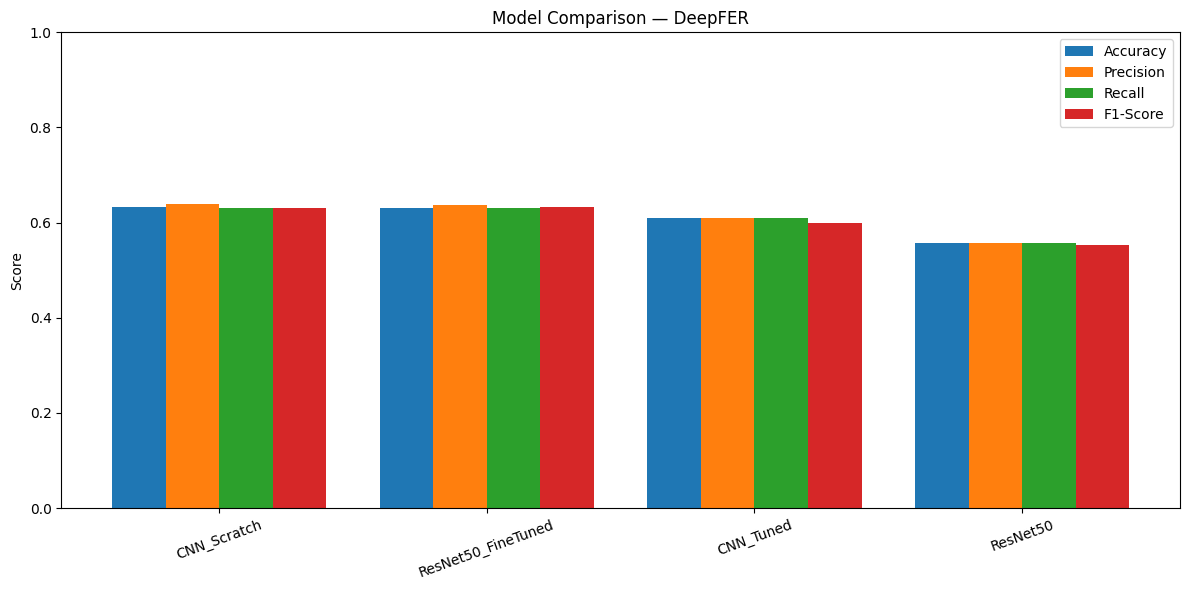

In [ ]:


metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df.index, rotation=20)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — DeepFER')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

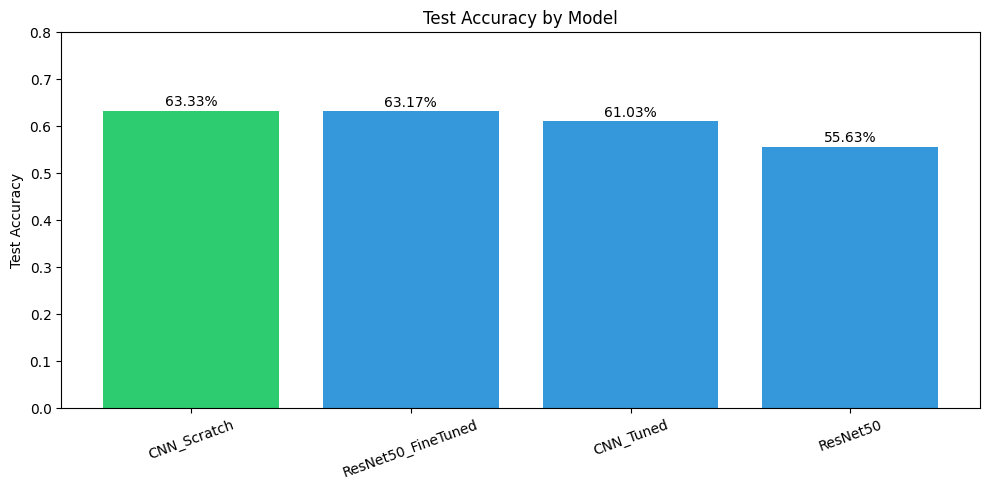

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if idx == comparison_df['Accuracy'].idxmax() else '#3498db' for idx in comparison_df.index]
ax.bar(comparison_df.index, comparison_df['Accuracy'], color=colors)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy by Model')
ax.set_ylim(0, 0.8)
for i, v in enumerate(comparison_df['Accuracy']):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Observation: Test Accuracy by Model

CNN_Scratch achieves the best test accuracy at 63.33%, narrowly edging out ResNet50_FineTuned (63.17%) — a difference of just 0.16 percentage points, which is likely within noise/random-seed variance rather than a meaningful gap.
CNN_Tuned follows closely at 61.03%, about 2.3 points behind the top performers.
ResNet50 (not fine-tuned) performs worst at 55.63%, roughly 7.7 points below the best model — suggesting that using ResNet50 as a frozen/off-the-shelf feature extractor without fine-tuning is notably less effective on this tas

In [ ]:
winner_by_accuracy = comparison_df['Accuracy'].idxmax()
winner_by_f1 = comparison_df['F1-Score'].idxmax()

print(f"Best by Accuracy: {winner_by_accuracy} ({comparison_df.loc[winner_by_accuracy, 'Accuracy']:.4f})")
print(f"Best by F1-Score: {winner_by_f1} ({comparison_df.loc[winner_by_f1, 'F1-Score']:.4f})")

FINAL_MODEL_NAME = "ResNet50_FineTuned"
print(f"\nSelected final model: {FINAL_MODEL_NAME}")
print("Reason: Near-identical overall accuracy to CNN Scratch, but stronger recall on")
print("minority/harder classes (disgust, fear) — more balanced across all 7 emotions,")
print("relevant for real-world deployment where all emotions matter, not just common ones.")

Best by Accuracy: CNN_Scratch (0.6333)
Best by F1-Score: ResNet50_FineTuned (0.6329)

Selected final model: ResNet50_FineTuned
Reason: Near-identical overall accuracy to CNN Scratch, but stronger recall on
minority/harder classes (disgust, fear) — more balanced across all 7 emotions,
relevant for real-world deployment where all emotions matter, not just common ones.


In [47]:
model_resnet_ft.save('/kaggle/working/emotion_final_model.keras')
print("Model saved successfully")

Model saved successfully


In [48]:
import json

label_mapping = {idx: cls for idx, cls in enumerate(CLASSES)}

with open('/kaggle/working/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

print("Label mapping saved:", label_mapping)

Label mapping saved: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [49]:
comparison_df.to_csv('/kaggle/working/model_comparison_results.csv')
print("Comparison table saved")
print(comparison_df)

Comparison table saved
                    Accuracy  Precision    Recall  F1-Score
CNN_Scratch         0.633300   0.640000  0.630000  0.630000
ResNet50_FineTuned  0.631652   0.637461  0.631652  0.632927
CNN_Tuned           0.610300   0.610000  0.610000  0.600000
ResNet50            0.556283   0.557325  0.556283  0.553657


In [51]:
import os

for fname in ['emotion_final_model.keras', 'label_mapping.json', 'model_comparison_results.csv']:
    fpath = f'/kaggle/working/{fname}'
    exists = os.path.exists(fpath)
    size = os.path.getsize(fpath) if exists else 0
    print(f"{fname}: exists={exists}, size={size/1024:.1f} KB")

emotion_final_model.keras: exists=True, size=211868.1 KB
label_mapping.json: exists=True, size=0.1 KB
model_comparison_results.csv: exists=True, size=0.3 KB


In [52]:
from tensorflow.keras.models import load_model

reloaded_model = load_model('/kaggle/working/emotion_final_model.keras')
test_loss_check, test_acc_check = reloaded_model.evaluate(test_ds_ft)
print(f"Reloaded model test accuracy: {test_acc_check:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 28s 98ms/step - accuracy: 0.6317 - loss: 1.0330
Reloaded model test accuracy: 0.6317
